**StudentLife — Unsupervised clustering + anomaly detection (NO PHQ used)**


1- Build per-user feature vectors from daily activity (no PHQ)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load daily activity only (no PHQ table)
sl_daily = pd.read_csv("cleaned/studentlife_activity_daily.csv")
act_cols = [c for c in sl_daily.columns if c.startswith("act_")]
assert act_cols, "act_ columns not found. Run StudentLife activity aggregation first."

# Optional: add behavior indicators from activity proportions (no PHQ)
def entropy_from_row(row):
    p = row[act_cols].values.astype(float)
    p = np.clip(p, 1e-12, 1.0)
    return float(-(p * np.log(p)).sum())

sl_daily["activity_entropy"] = sl_daily.apply(entropy_from_row, axis=1)
sl_daily["dominant_activity_share"] = sl_daily[act_cols].max(axis=1)

sed_cols = [c for c in act_cols if c in ("act_0","act_1")]
hi_cols  = [c for c in act_cols if c in ("act_2","act_3")]
sl_daily["sedentary_share_proxy"] = sl_daily[sed_cols].sum(axis=1) if sed_cols else np.nan
sl_daily["active_share_proxy"]    = sl_daily[hi_cols].sum(axis=1) if hi_cols else np.nan

# Per-user representation: mean + std across days
user_feats = sl_daily.groupby("user_id")[act_cols + [
    "activity_entropy","dominant_activity_share","sedentary_share_proxy","active_share_proxy"
]].agg(["mean","std"])

user_feats.columns = ["_".join(c) for c in user_feats.columns]
user_feats = user_feats.reset_index()

print("StudentLife unsupervised feature table:", user_feats.shape)
display(user_feats.head())

X_sl = user_feats.drop(columns=["user_id"]).fillna(0).values
X_sl = StandardScaler().fit_transform(X_sl)

print("X_sl shape:", X_sl.shape, "| users:", user_feats["user_id"].nunique())


StudentLife unsupervised feature table: (49, 17)


,user_id,act_0_mean,act_0_std,act_1_mean,act_1_std,act_2_mean,act_2_std,act_3_mean,act_3_std,activity_entropy_mean,activity_entropy_std,dominant_activity_share_mean,dominant_activity_share_std,sedentary_share_proxy_mean,sedentary_share_proxy_std,active_share_proxy_mean,active_share_proxy_std
0,u00,0.862789,0.082776,0.073460,0.048374,0.020051,0.023469,0.043700,0.045938,0.487922,0.207079,0.862789,0.082776,0.936248,0.052641,0.063752,0.052641
1,u01,0.920276,0.041363,0.045604,0.028452,0.020754,0.010243,0.013366,0.013478,0.339574,0.128411,0.920276,0.041363,0.965880,0.018063,0.034120,0.018063
2,u02,0.921551,0.030209,0.055287,0.018555,0.001276,0.001581,0.021886,0.017332,0.317320,0.095116,0.921551,0.030209,0.976838,0.017502,0.023162,0.017502
3,u03,0.983813,0.020266,0.011357,0.014133,0.001066,0.002322,0.003764,0.005522,0.081068,0.093166,0.983813,0.020266,0.995170,0.006948,0.004830,0.006948
4,u04,0.862795,0.057079,0.071628,0.027040,0.033882,0.018170,0.031695,0.061264,0.495306,0.129256,0.862795,0.057079,0.934423,0.057567,0.065577,0.057567


X_sl shape: (49, 16) | users: 49


2- KMeans clustering (auto-k) + Isolation Forest anomaly score

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

n = X_sl.shape[0]
if n < 2:
    print("Not enough users for clustering/anomaly detection.")
else:
    # ---- KMeans: choose k using silhouette, but never exceed n ----
    k_candidates = [k for k in range(2, min(7, n) + 1)]
    best_k, best_s = None, -1

    for k in k_candidates:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_sl)
        s = silhouette_score(X_sl, labels)
        print(f"k={k}, silhouette={s:.3f}")
        if s > best_s:
            best_k, best_s = k, s

    print("Best k:", best_k, "silhouette:", round(best_s, 3))

    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    user_feats["cluster"] = km.fit_predict(X_sl)
    user_feats["kmeans_score"] = np.min(km.transform(X_sl), axis=1)  # distance-to-centroid

    # ---- Isolation Forest anomaly score ----
    iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
    iso.fit(X_sl)
    user_feats["iso_score"] = -iso.score_samples(X_sl)
    user_feats["iso_abnormal"] = (iso.predict(X_sl) == -1).astype(int)

    print("Abnormal users (IF):", user_feats["iso_abnormal"].sum())
    display(user_feats.sort_values("iso_score", ascending=False).head(10))

    # Save results
    user_feats.to_csv("cleaned/studentlife_unsupervised_user.csv", index=False)
    print("Saved: cleaned/studentlife_unsupervised_user.csv")


k=2, silhouette=0.428
k=3, silhouette=0.390
k=4, silhouette=0.290
k=5, silhouette=0.308
k=6, silhouette=0.220
k=7, silhouette=0.243
Best k: 2 silhouette: 0.428
Abnormal users (IF): 5


,user_id,act_0_mean,act_0_std,act_1_mean,act_1_std,act_2_mean,act_2_std,act_3_mean,act_3_std,activity_entropy_mean,...,dominant_activity_share_mean,dominant_activity_share_std,sedentary_share_proxy_mean,sedentary_share_proxy_std,active_share_proxy_mean,active_share_proxy_std,cluster,kmeans_score,iso_score,iso_abnormal
42,u52,0.770641,0.257732,0.098150,0.062593,0.074229,0.247083,0.056980,0.093848,0.475489,...,0.846037,0.111861,0.868791,0.269665,0.131209,0.269665,1,12.814271,0.778959,1
48,u59,0.831295,0.101441,0.073740,0.037772,0.017993,0.010104,0.076972,0.093051,0.556786,...,0.831295,0.101441,0.905035,0.097832,0.094965,0.097832,1,4.003252,0.630210,1
22,u25,0.882080,0.106741,0.051429,0.037088,0.014768,0.024679,0.051723,0.071927,0.411697,...,0.882080,0.106741,0.933510,0.088513,0.066490,0.088513,1,2.460481,0.566317,1
3,u03,0.983813,0.020266,0.011357,0.014133,0.001066,0.002322,0.003764,0.005522,0.081068,...,0.983813,0.020266,0.995170,0.006948,0.004830,0.006948,0,3.862374,0.559075,1
40,u50,0.963317,0.081585,0.014499,0.012734,0.000241,0.000506,0.021942,0.080410,0.130614,...,0.964443,0.074653,0.977816,0.080368,0.022184,0.080368,0,4.101280,0.550120,1
37,u46,0.848553,0.051145,0.087944,0.044643,0.028859,0.013190,0.034644,0.034266,0.544791,...,0.848553,0.051145,0.936497,0.037051,0.063503,0.037051,1,3.823130,0.529721,0
28,u34,0.889087,0.095870,0.039181,0.036309,0.005395,0.007695,0.066337,0.069798,0.388672,...,0.889087,0.095870,0.928268,0.072689,0.071732,0.072689,1,2.583420,0.529011,0
0,u00,0.862789,0.082776,0.073460,0.048374,0.020051,0.023469,0.043700,0.045938,0.487922,...,0.862789,0.082776,0.936248,0.052641,0.063752,0.052641,1,1.741506,0.521942,0
4,u04,0.862795,0.057079,0.071628,0.027040,0.033882,0.018170,0.031695,0.061264,0.495306,...,0.862795,0.057079,0.934423,0.057567,0.065577,0.057567,1,2.905341,0.521419,0
33,u42,0.934912,0.118837,0.035029,0.113819,0.002741,0.002804,0.027318,0.033211,0.218283,...,0.947512,0.052784,0.969942,0.034318,0.030058,0.034318,0,5.677544,0.497869,0


Saved: cleaned/studentlife_unsupervised_user.csv


**ExtraSensory — Unsupervised for non labeled**

1- per-user clustering using sensor features only

In [3]:

from sklearn.preprocessing import StandardScaler

es = pd.read_csv("cleaned/extrasensory_clean_core_labels_normalized.csv")

# Remove label columns completely (NO labels used)
feature_cols = [c for c in es.columns if (not c.startswith("label:")) and c != "user_id"]
assert feature_cols, "No sensor feature columns found."

# Build per-user representation: mean + std across windows
es_user = es.groupby("user_id")[feature_cols].agg(["mean","std"])
es_user.columns = ["_".join(c) for c in es_user.columns]
es_user = es_user.reset_index()

print("ExtraSensory per-user feature table:", es_user.shape)
display(es_user.head())

X_es = es_user.drop(columns=["user_id"]).fillna(0).values
X_es = StandardScaler().fit_transform(X_es)

print("X_es shape:", X_es.shape, "| users:", es_user["user_id"].nunique())


ExtraSensory per-user feature table: (2, 451)


,user_id,timestamp_mean,timestamp_std,raw_acc:magnitude_stats:mean_mean,raw_acc:magnitude_stats:mean_std,raw_acc:magnitude_stats:std_mean,raw_acc:magnitude_stats:std_std,raw_acc:magnitude_stats:moment3_mean,raw_acc:magnitude_stats:moment3_std,raw_acc:magnitude_stats:moment4_mean,...,location:min_altitude_mean,location:min_altitude_std,location:max_altitude_mean,location:max_altitude_std,location:best_vertical_accuracy_mean,location:best_vertical_accuracy_std,lf_measurements:proximity_mean,lf_measurements:proximity_std,lf_measurements:screen_brightness_mean,lf_measurements:screen_brightness_std
0,user1,1.637944,0.020542,0.219287,0.730990,0.118569,1.356843,0.031642,0.929442,0.038092,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,user2,-0.610264,0.016835,-0.081702,1.071913,-0.044176,0.824424,-0.011789,1.024860,-0.014192,...,6.149335e-16,1.0,-2.740868e-17,1.0,-1.888985e-16,1.0,0.0,0.0,-1.289734e-14,1.0


X_es shape: (2, 450) | users: 2


2- Cluster + anomaly detection

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest


n = X_es.shape[0]
print("ExtraSensory users (samples):", n)

# ----------------------------
# 1) KMeans (only if n >= 3)
# ----------------------------
# With n=2, clustering is trivial and silhouette is not useful.
if n >= 3:
    k_candidates = [k for k in range(2, min(6, n) + 1)]
    best_k, best_s = None, -1

    for k in k_candidates:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_es)

        # silhouette needs >=2 clusters and not all points in one cluster
        if len(set(labels)) < 2:
            continue

        s = silhouette_score(X_es, labels)
        print(f"k={k}, silhouette={s:.3f}")
        if s > best_s:
            best_k, best_s = k, s

    print("Best k:", best_k, "silhouette:", round(best_s, 3))

    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    es_user["cluster"] = km.fit_predict(X_es)
    es_user["kmeans_score"] = np.min(km.transform(X_es), axis=1)

else:
    print("Skipping KMeans: need at least 3 users for meaningful clustering.")
    es_user["cluster"] = 0
    es_user["kmeans_score"] = 0.0


# ----------------------------
# 2) Isolation Forest (only if n >= 2)
# ----------------------------
if n >= 2:
    # contamination must be < 0.5 for very small n
    contamination = min(0.1, (n-1)/n - 1e-6)

    iso = IsolationForest(n_estimators=300, contamination=contamination, random_state=42)
    iso.fit(X_es)

    es_user["iso_score"] = -iso.score_samples(X_es)  # higher = more abnormal
    es_user["iso_abnormal"] = (iso.predict(X_es) == -1).astype(int)

    print("Abnormal users (IF):", es_user["iso_abnormal"].sum())
    display(es_user.sort_values("iso_score", ascending=False).head(10))

else:
    print("Skipping Isolation Forest: need at least 2 users.")
    es_user["iso_score"] = 0.0
    es_user["iso_abnormal"] = 0


# Save
es_user.to_csv("cleaned/extrasensory_unsupervised_user.csv", index=False)
print("Saved: cleaned/extrasensory_unsupervised_user.csv")



ExtraSensory users (samples): 2
Skipping KMeans: need at least 3 users for meaningful clustering.
Abnormal users (IF): 0


,user_id,timestamp_mean,timestamp_std,raw_acc:magnitude_stats:mean_mean,raw_acc:magnitude_stats:mean_std,raw_acc:magnitude_stats:std_mean,raw_acc:magnitude_stats:std_std,raw_acc:magnitude_stats:moment3_mean,raw_acc:magnitude_stats:moment3_std,raw_acc:magnitude_stats:moment4_mean,...,location:best_vertical_accuracy_mean,location:best_vertical_accuracy_std,lf_measurements:proximity_mean,lf_measurements:proximity_std,lf_measurements:screen_brightness_mean,lf_measurements:screen_brightness_std,cluster,kmeans_score,iso_score,iso_abnormal
0,user1,1.637944,0.020542,0.219287,0.730990,0.118569,1.356843,0.031642,0.929442,0.038092,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.5,0
1,user2,-0.610264,0.016835,-0.081702,1.071913,-0.044176,0.824424,-0.011789,1.024860,-0.014192,...,-1.888985e-16,1.0,0.0,0.0,-1.289734e-14,1.0,0,0.0,0.5,0


Saved: cleaned/extrasensory_unsupervised_user.csv


**Depresjon**

In [7]:
import zipfile, re, os


ZIP_PATH = "depresjon.zip"
z = zipfile.ZipFile(ZIP_PATH)

files = [f for f in z.namelist() if f.endswith(".csv") and ("data/control/" in f or "data/condition/" in f)]
print("Participant CSV count:", len(files))

def parse_dt(df):
    df = df.copy()

    if "timestamp" in df.columns:
        ts = df["timestamp"]

        # If timestamp is numeric, decide if seconds or milliseconds
        if np.issubdtype(ts.dtype, np.number):
            med = np.nanmedian(ts.values)
            if med > 1e12:      # milliseconds epoch
                dt = pd.to_datetime(ts, unit="ms", errors="coerce")
            elif med > 1e9:     # seconds epoch
                dt = pd.to_datetime(ts, unit="s", errors="coerce")
            else:
                dt = pd.to_datetime(ts, errors="coerce")
        else:
            # If timestamp is string datetime
            dt = pd.to_datetime(ts, errors="coerce")

    elif "date" in df.columns:
        dt = pd.to_datetime(df["date"], errors="coerce")
    else:
        return pd.Series([pd.NaT] * len(df))

    return dt

def longest_zero_run(arr):
    max_run = run = 0
    for v in arr:
        if v == 1:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

def extract_participant_features(df):
    df = df.copy()

    df["dt"] = parse_dt(df)
    df = df.dropna(subset=["dt"]).copy()

    # If time parsing failed, skip this participant
    if len(df) == 0:
        return None

    if "activity" not in df.columns:
        return None

    df["activity"] = pd.to_numeric(df["activity"], errors="coerce").fillna(0)

    df["day"] = df["dt"].dt.date
    df["hour"] = df["dt"].dt.hour

    daily_total = df.groupby("day")["activity"].sum()
    daily_mean = daily_total.mean()
    daily_std  = daily_total.std(ddof=0) if len(daily_total) > 1 else 0.0
    daily_cv   = daily_std / (daily_mean + 1e-6)

    mean_act = df["activity"].mean()
    std_act  = df["activity"].std(ddof=0)
    frac_zero = (df["activity"] == 0).mean()

    day_mask = df["hour"].between(8, 19)
    night_mask = ~day_mask
    day_mean = df.loc[day_mask, "activity"].mean() if day_mask.any() else 0.0
    night_mean = df.loc[night_mask, "activity"].mean() if night_mask.any() else 0.0
    night_day_ratio = (night_mean + 1e-6) / (day_mean + 1e-6)

    hourly = df.groupby("hour")["activity"].mean().reindex(range(24), fill_value=0).values.astype(float)
    p = hourly / (hourly.sum() + 1e-12)
    p = np.clip(p, 1e-12, 1.0)
    hourly_entropy = float(-(p * np.log(p)).sum())

    df_sorted = df.sort_values("dt")
    zero_run = longest_zero_run((df_sorted["activity"] == 0).astype(int).values)

    return {
        "mean_activity": float(mean_act),
        "std_activity": float(std_act),
        "frac_zero_activity": float(frac_zero),
        "daily_total_mean": float(daily_mean),
        "daily_total_std": float(daily_std),
        "daily_total_cv": float(daily_cv),
        "day_mean_activity": float(day_mean),
        "night_mean_activity": float(night_mean),
        "night_day_ratio": float(night_day_ratio),
        "hourly_entropy": float(hourly_entropy),
        "longest_zero_run": float(zero_run),
        "n_days": int(daily_total.shape[0]),
        "n_samples": int(df.shape[0]),
    }

rows = []
skipped = 0

for f in files:
    with z.open(f) as fh:
        df = pd.read_csv(fh)

    # UNIQUE ID (does not use labels as target; it's just an identifier)
    base = os.path.splitext(os.path.basename(f))[0]   # "control_1" or "condition_1"
    user_id = base

    feats = extract_participant_features(df)
    if feats is None:
        skipped += 1
        continue

    feats["user_id"] = user_id
    rows.append(feats)

feat_df = pd.DataFrame(rows)
print("Feature table shape:", feat_df.shape)
print("Skipped participants (time parse failed or missing columns):", skipped)
display(feat_df.head())

# sanity check
print("Any NaN columns (fraction):")
display(feat_df.isna().mean().sort_values(ascending=False).head(10))

print("Duplicate user_ids:", feat_df["user_id"].duplicated().sum())

Participant CSV count: 55
Feature table shape: (55, 14)
Skipped participants (time parse failed or missing columns): 0


,mean_activity,std_activity,frac_zero_activity,daily_total_mean,daily_total_std,daily_total_cv,day_mean_activity,night_mean_activity,night_day_ratio,hourly_entropy,longest_zero_run,n_days,n_samples,user_id
0,109.534060,232.731897,0.519584,149438.687500,86781.097757,0.580714,145.507480,72.797870,0.500303,2.980400,439.0,16,21829,condition_15
1,184.934453,415.240977,0.415773,254932.142857,141784.538578,0.556166,257.029580,108.379594,0.421662,2.854249,75.0,14,19299,condition_8
2,71.104090,136.134329,0.476039,94866.187500,26813.437206,0.282645,71.045321,71.161481,1.001635,3.134755,589.0,16,21347,condition_18
3,167.245987,298.712680,0.374959,224663.625000,88989.738046,0.396102,250.567474,84.750000,0.338232,2.851976,481.0,16,21493,condition_5
4,196.416414,334.692134,0.457146,263112.062500,83459.657327,0.317202,296.031976,98.341204,0.332198,2.901462,480.0,16,21433,condition_6


Any NaN columns (fraction):


mean_activity          0.0
std_activity           0.0
frac_zero_activity     0.0
daily_total_mean       0.0
daily_total_std        0.0
daily_total_cv         0.0
day_mean_activity      0.0
night_mean_activity    0.0
night_day_ratio        0.0
hourly_entropy         0.0
dtype: float64

Duplicate user_ids: 0


KMeans + automatic K selection (silhouette)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cols = [c for c in feat_df.columns if c != "user_id"]
X = feat_df[X_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

N = X_scaled.shape[0]
k_candidates = list(range(2, min(9, N)))  # try 2..8 (or up to N-1)
scores = {}

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

best_k = max(scores, key=scores.get)
print("Silhouette scores:", scores)
print("Best K:", best_k)

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
feat_df["cluster"] = km_best.fit_predict(X_scaled)

feat_df[["user_id", "cluster"]].head(10)


Silhouette scores: {2: 0.25021456040327655, 3: 0.302805481165298, 4: 0.30493833050396274, 5: 0.31010980795684956, 6: 0.24288785742235977, 7: 0.25056461095380955, 8: 0.20771888851039663}
Best K: 5


,user_id,cluster
0,condition_15,0
1,condition_8,0
2,condition_18,3
3,condition_5,0
4,condition_6,0
5,condition_22,0
6,condition_21,0
7,condition_12,0
8,condition_19,0
9,condition_20,0


PCA plot to visualize clusters

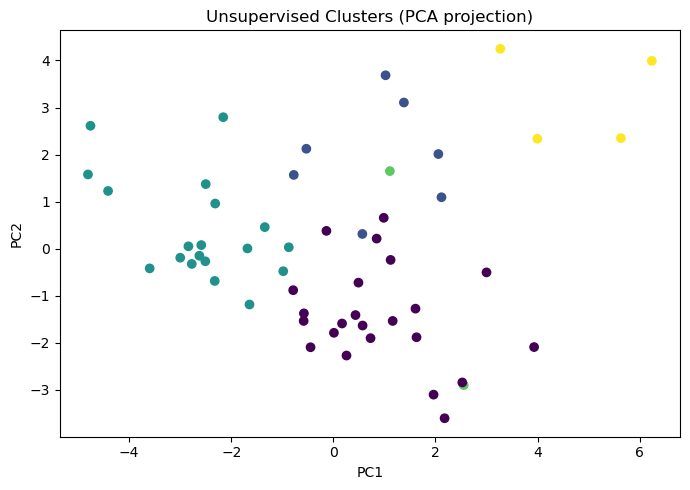

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=feat_df["cluster"])
plt.title("Unsupervised Clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


Isolation Forest anomaly detection

In [10]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
iso.fit(X_scaled)

# higher = more abnormal (negate)
feat_df["anomaly_score"] = -iso.score_samples(X_scaled)
feat_df["is_anomaly"] = (iso.predict(X_scaled) == -1).astype(int)

print("Anomalies flagged:", feat_df["is_anomaly"].sum())
display(feat_df.sort_values("anomaly_score", ascending=False).head(10)[["user_id","cluster","anomaly_score","is_anomaly"]])


Anomalies flagged: 6


,user_id,cluster,anomaly_score,is_anomaly
43,control_3,4,0.632698,1
38,control_32,4,0.600735,1
37,control_2,2,0.579265,1
33,control_31,4,0.567515,1
47,control_21,3,0.562839,1
2,condition_18,3,0.549185,1
29,control_7,1,0.544617,0
9,condition_20,0,0.542470,0
6,condition_21,0,0.533846,0
45,control_6,1,0.524534,0


In [11]:
import os
os.makedirs("cleaned", exist_ok=True)

feat_df.to_csv("cleaned/depresjon_unsupervised_features_clusters.csv", index=False)
print("Saved: cleaned/depresjon_unsupervised_features_clusters.csv")


Saved: cleaned/depresjon_unsupervised_features_clusters.csv


**best anomaly-signature models**

1 - StudentLife


In [17]:

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge

# ---------- Load daily indicators ----------
sl = pd.read_csv("cleaned/studentlife_indicators_daily.csv")
sl["date"] = pd.to_datetime(sl["date"], errors="coerce")
sl = sl.dropna(subset=["date"]).sort_values(["user_id","date"]).reset_index(drop=True)

# Use only indicator columns (you can add act_* if you want)
ind_cols = [c for c in sl.columns if c in [
    "activity_entropy","dominant_activity_share","sedentary_share_proxy","active_share_proxy"
]]
print("Using indicator columns:", ind_cols)

X = sl[ind_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------- Model A: Isolation Forest (daily anomaly) ----------
iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
iso.fit(X_scaled)

sl["anomaly_score_iso"] = -iso.score_samples(X_scaled)          # higher = more abnormal
sl["is_anomaly_iso"] = (iso.predict(X_scaled) == -1).astype(int)

# Aggregate per user: anomaly signature strength
sl_user = sl.groupby("user_id").agg(
    iso_score_mean=("anomaly_score_iso","mean"),
    iso_score_p95=("anomaly_score_iso", lambda x: np.quantile(x, 0.95)),
    iso_anom_frac=("is_anomaly_iso","mean")
).reset_index()

print("StudentLife per-user anomaly summary:")
display(sl_user.sort_values("iso_score_p95", ascending=False).head(10))

# ---------- Model B: Simple CUSUM change-point proxy (per user on sedentary) ----------
def cusum_changes(x, k=0.0, h=3.0):
    """
    Very simple CUSUM detector on a 1D series.
    Returns index positions where shift is flagged.
    """
    s_pos, s_neg = 0.0, 0.0
    flags = []
    mu = np.mean(x) if len(x) else 0.0
    sd = np.std(x) + 1e-6
    z = (x - mu) / sd
    for i, v in enumerate(z):
        s_pos = max(0.0, s_pos + v - k)
        s_neg = min(0.0, s_neg + v + k)
        if s_pos > h or abs(s_neg) > h:
            flags.append(i)
            s_pos, s_neg = 0.0, 0.0
    return flags

sl["cusum_flag"] = 0
for uid, g in sl.groupby("user_id"):
    if "sedentary_share_proxy" not in g.columns:
        continue
    x = g["sedentary_share_proxy"].fillna(0).values
    idxs = cusum_changes(x, h=3.0)
    if idxs:
        sl.loc[g.index[idxs], "cusum_flag"] = 1

# ---------- Model C: Forecast residual anomaly (Ridge with lags) ----------
# Predict next-day sedentary_share_proxy from past 7 days of indicators (pooled across users)
L = 7
rows = []
for uid, g in sl.groupby("user_id"):
    g = g.sort_values("date")
    if len(g) <= L:
        continue
    arr = g[ind_cols].fillna(0).values
    target = g["sedentary_share_proxy"].fillna(0).values
    for t in range(L, len(g)):
        x_lag = arr[t-L:t].reshape(-1)   # flatten L days x features
        rows.append((uid, g.iloc[t]["date"], x_lag, target[t]))

if rows:
    Xlag = np.vstack([r[2] for r in rows])
    ylag = np.array([r[3] for r in rows])

    model = Ridge(alpha=1.0, random_state=42)
    model.fit(Xlag, ylag)
    pred = model.predict(Xlag)
    resid = np.abs(ylag - pred)

    resid_df = pd.DataFrame({
        "user_id":[r[0] for r in rows],
        "date":[r[1] for r in rows],
        "forecast_abs_error": resid
    })

    # Merge back
    sl = sl.merge(resid_df, on=["user_id","date"], how="left")
else:
    sl["forecast_abs_error"] = np.nan
    print("Not enough sequence length for forecast model.")

# ---------- Save ----------
sl.to_csv("cleaned/studentlife_anomaly_daily.csv", index=False)
sl_user.to_csv("cleaned/studentlife_anomaly_user.csv", index=False)
print("Saved:")
print("  cleaned/studentlife_anomaly_daily.csv")
print("  cleaned/studentlife_anomaly_user.csv")


Using indicator columns: ['activity_entropy', 'dominant_activity_share', 'sedentary_share_proxy', 'active_share_proxy']
StudentLife per-user anomaly summary:


,user_id,iso_score_mean,iso_score_p95,iso_anom_frac
42,u52,0.506854,0.809646,0.242424
48,u59,0.508417,0.764270,0.298507
28,u34,0.483295,0.727756,0.235294
4,u04,0.471065,0.683311,0.137931
24,u30,0.468281,0.681742,0.169231
22,u25,0.480752,0.653816,0.240000
0,u00,0.482399,0.644908,0.303030
13,u15,0.459959,0.640494,0.145833
30,u36,0.456875,0.630942,0.164179
26,u32,0.445296,0.616541,0.158730


Saved:
  cleaned/studentlife_anomaly_daily.csv
  cleaned/studentlife_anomaly_user.csv


In [21]:

sl = pd.read_csv("cleaned/studentlife_anomaly_daily.csv")

# Choose feature columns to compare (indicators + optional act_*)
feature_cols = [c for c in sl.columns if c in [
    "activity_entropy", "dominant_activity_share",
    "sedentary_share_proxy", "active_share_proxy"
] or c.startswith("act_")]

assert "is_anomaly_iso" in sl.columns, "Run StudentLife Isolation Forest first to create is_anomaly_iso."

abn = sl[sl["is_anomaly_iso"] == 1]
nor = sl[sl["is_anomaly_iso"] == 0]

diff = (abn[feature_cols].mean() - nor[feature_cols].mean()).sort_values(key=lambda s: s.abs(), ascending=False)

top5 = pd.DataFrame({
    "feature": diff.index[:5],
    "mean_abnormal": abn[diff.index[:5]].mean().values,
    "mean_normal": nor[diff.index[:5]].mean().values,
    "mean_diff(abn-normal)": diff.values[:5]
})

print("StudentLife — Top 5 abnormal-defining features (mean difference):")
display(top5)


StudentLife — Top 5 abnormal-defining features (mean difference):


,feature,mean_abnormal,mean_normal,mean_diff(abn-normal)
0,activity_entropy,0.612540,0.271529,0.341010
1,act_0,0.774993,0.936340,-0.161347
2,dominant_activity_share,0.794802,0.936340,-0.141538
3,sedentary_share_proxy,0.854777,0.974608,-0.119831
4,active_share_proxy,0.145223,0.025392,0.119831


2 - ExtraSensory

In [19]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

es = pd.read_csv("cleaned/extrasensory_clean_core_labels_normalized.csv")

# Features = everything except user_id and label columns
feat_cols = [c for c in es.columns if c != "user_id" and not c.startswith("label:")]
X = es[feat_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----- Representation learning (lightweight): PCA embeddings -----
n_comp = min(20, X_scaled.shape[1], X_scaled.shape[0]-1)
pca = PCA(n_components=max(2, n_comp), random_state=42)
Z = pca.fit_transform(X_scaled)

# ----- Anomaly detection on embeddings -----
iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
iso.fit(Z)

es["anomaly_score_iso"] = -iso.score_samples(Z)
es["is_anomaly_iso"] = (iso.predict(Z) == -1).astype(int)

# Aggregate to per-user anomaly signatures
es_user = es.groupby("user_id").agg(
    iso_score_mean=("anomaly_score_iso","mean"),
    iso_score_p95=("anomaly_score_iso", lambda x: np.quantile(x, 0.95)),
    iso_anom_frac=("is_anomaly_iso","mean"),
    n_windows=("is_anomaly_iso","size")
).reset_index()

display(es_user.sort_values("iso_score_p95", ascending=False).head(10))

# Save
es.to_csv("cleaned/extrasensory_anomaly_windows.csv", index=False)
es_user.to_csv("cleaned/extrasensory_anomaly_user.csv", index=False)
print("Saved:")
print("  cleaned/extrasensory_anomaly_windows.csv")
print("  cleaned/extrasensory_anomaly_user.csv")


,user_id,iso_score_mean,iso_score_p95,iso_anom_frac,n_windows
0,user1,0.423248,0.523719,0.133134,2674
1,user2,0.403553,0.489765,0.087641,7177


Saved:
  cleaned/extrasensory_anomaly_windows.csv
  cleaned/extrasensory_anomaly_user.csv


In [23]:

es = pd.read_csv("cleaned/extrasensory_anomaly_windows.csv")

# Compare sensor features + label rates if present
feature_cols = [c for c in es.columns if c not in ["user_id", "is_anomaly_iso", "anomaly_score_iso"]]

assert "is_anomaly_iso" in es.columns, "Run ExtraSensory Isolation Forest first to create is_anomaly_iso."

abn = es[es["is_anomaly_iso"] == 1]
nor = es[es["is_anomaly_iso"] == 0]

diff = (abn[feature_cols].mean() - nor[feature_cols].mean()).sort_values(key=lambda s: s.abs(), ascending=False)

top5 = pd.DataFrame({
    "feature": diff.index[:5],
    "mean_abnormal": abn[diff.index[:5]].mean().values,
    "mean_normal": nor[diff.index[:5]].mean().values,
    "mean_diff(abn-normal)": diff.values[:5]
})

print("ExtraSensory — Top 5 abnormal-defining features (mean difference):")
display(top5)


ExtraSensory — Top 5 abnormal-defining features (mean difference):


,feature,mean_abnormal,mean_normal,mean_diff(abn-normal)
0,raw_acc:magnitude_stats:std,1.710700,-0.190056,1.900756
1,raw_acc:magnitude_spectrum:log_energy_band2,1.710456,-0.190029,1.900486
2,raw_acc:magnitude_spectrum:log_energy_band3,1.683890,-0.187078,1.870968
3,proc_gyro:3d:std_y,1.661318,-0.184570,1.845888
4,raw_acc:3d:std_z,1.657108,-0.184102,1.841210


3 - Depresjon

In [20]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest


X_cols = [c for c in feat_df.columns if c != "user_id"]
X = feat_df[X_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----- Choose best K by silhouette -----
N = X_scaled.shape[0]
k_candidates = list(range(2, min(9, N)))
scores = {}
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

best_k = max(scores, key=scores.get)
print("Silhouette scores:", scores)
print("Best K:", best_k)

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
feat_df["cluster"] = km_best.fit_predict(X_scaled)

# ----- Isolation Forest anomalies -----
iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
iso.fit(X_scaled)
feat_df["anomaly_score_iso"] = -iso.score_samples(X_scaled)
feat_df["is_anomaly_iso"] = (iso.predict(X_scaled) == -1).astype(int)

print("Anomalies flagged:", feat_df["is_anomaly_iso"].sum())
display(feat_df.sort_values("anomaly_score_iso", ascending=False).head(10)[["user_id","cluster","anomaly_score_iso","is_anomaly_iso"]])

# Save
feat_df.to_csv("cleaned/depresjon_anomaly_clusters.csv", index=False)
print("Saved: cleaned/depresjon_anomaly_clusters.csv")


Silhouette scores: {2: 0.4396987707903998, 3: 0.3071044924831312, 4: 0.31347515016966293, 5: 0.33518905956210626, 6: 0.26944032944980884, 7: 0.2740008715666352, 8: 0.21762631222869283}
Best K: 2
Anomalies flagged: 6


,user_id,cluster,anomaly_score_iso,is_anomaly_iso
43,control_3,1,0.663949,1
38,control_32,1,0.618478,1
2,condition_18,1,0.605694,1
37,control_2,0,0.601427,1
47,control_21,1,0.599495,1
33,control_31,1,0.594085,1
9,condition_20,0,0.539328,0
50,control_1,1,0.538221,0
29,control_7,0,0.521948,0
6,condition_21,0,0.521235,0


Saved: cleaned/depresjon_anomaly_clusters.csv


In [24]:


dp = pd.read_csv("cleaned/depresjon_anomaly_clusters.csv")

# Feature columns (exclude identifiers and model outputs)
exclude = {"user_id", "cluster", "is_anomaly_iso", "anomaly_score_iso"}
feature_cols = [c for c in dp.columns if c not in exclude]

assert "is_anomaly_iso" in dp.columns, "Run Depresjon Isolation Forest first to create is_anomaly_iso."

abn = dp[dp["is_anomaly_iso"] == 1]
nor = dp[dp["is_anomaly_iso"] == 0]

diff = (abn[feature_cols].mean() - nor[feature_cols].mean()).sort_values(key=lambda s: s.abs(), ascending=False)

top5 = pd.DataFrame({
    "feature": diff.index[:5],
    "mean_abnormal": abn[diff.index[:5]].mean().values,
    "mean_normal": nor[diff.index[:5]].mean().values,
    "mean_diff(abn-normal)": diff.values[:5]
})

print("Depresjon — Top 5 abnormal-defining features (mean difference):")
display(top5)


Depresjon — Top 5 abnormal-defining features (mean difference):


,feature,mean_abnormal,mean_normal,mean_diff(abn-normal)
0,daily_total_mean,214525.719406,265529.853830,-51004.134424
1,daily_total_std,164166.753075,139407.092908,24759.660168
2,n_samples,42195.166667,26908.877551,15286.289116
3,longest_zero_run,5579.833333,1109.959184,4469.874150
4,day_mean_activity,205.805166,278.707037,-72.901871


Why these models are suitable for learning mental-health anomaly signatures
- These datasets do not include direct anomaly ground-truth labels, so unsupervised approaches are appropriate.
- Isolation Forest and clustering methods learn the structure of typical behavior patterns and flag deviations as anomalies.
- The “signature” is obtained by comparing abnormal vs normal feature means (Top-5 defining indicators), producing interpretable behavioral patterns (e.g., higher night/day activity ratio, lower entropy, higher sedentary share).